# Análisis Exploratorio de Datos (EDA)
Este notebook realiza un análisis exploratorio completo del dataset 'Student Exam Performance' de Kaggle.

## 1. Carga de Datos
Usamos `kagglehub` para descargar el dataset.

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from ydata_profiling import ProfileReport

# Descargar el dataset
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
print("Ruta del dataset:", path)

import os
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))
df.head()

100%|██████████| 8.70k/8.70k [00:00<00:00, 2.40MB/s]

Extracting files...
Ruta del dataset: C:\Users\oaceb\.cache\kagglehub\datasets\spscientist\students-performance-in-exams\versions\1


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 2. Estadísticas Descriptivas
Cálculo de Media, Moda, Varianza, Desviación Típica, Cuartiles, Duplicados y Nulos.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [2]:
# Estadísticas generales
stats_df = df.describe().T
stats_df['mode'] = df.select_dtypes(include=[np.number]).mode().iloc[0]
stats_df['variance'] = df.select_dtypes(include=[np.number]).var()
print("Estadísticas descriptivas:")
display(stats_df)

print("\nObservaciones duplicadas:", df.duplicated().sum())
print("Valores nulos por columna:")
print(df.isnull().sum())

Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max,mode,variance
math score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0,65,229.918998
reading score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0,72,213.165605
writing score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0,74,230.907992



Observaciones duplicadas: 0
Valores nulos por columna:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [8]:
# Estadísticas generales
stats_df = df.describe(include='object').T
print("Estadísticas descriptivas:")
display(stats_df)

print("\nObservaciones duplicadas:", df.duplicated().sum())
print("Valores nulos por columna:")
print(df.isnull().sum())

Estadísticas descriptivas:


,count,unique,top,freq
gender,1000,2,female,518
race/ethnicity,1000,5,group C,319
parental level of education,1000,6,some college,226
lunch,1000,2,standard,645
test preparation course,1000,2,none,642



Observaciones duplicadas: 0
Valores nulos por columna:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


## 3. Histogramas y Boxplots
Incluimos el cálculo de Curtosis y Skewness (Asimetría).

### Fórmulas Matemáticas:

**Sesgo (Skewness):**
$$ S = \frac{\frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^3}{ \sigma^3 } $$

**Curtosis (Kurtosis):**
$$ K = \frac{\frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^4}{\sigma^4} -3 $$


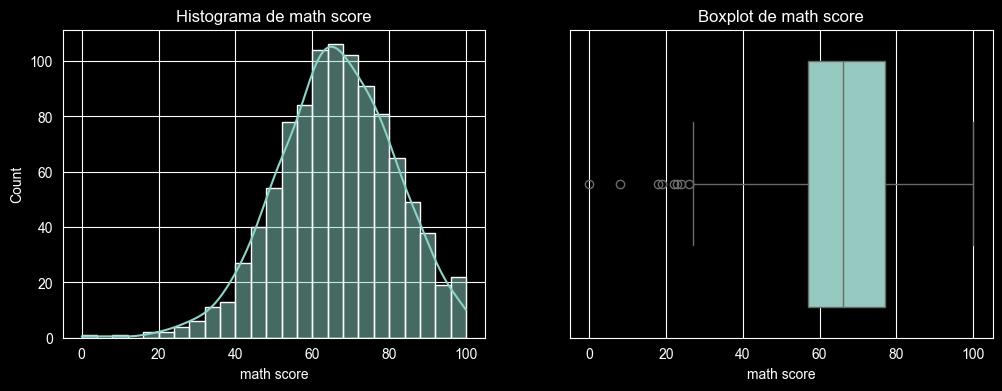

math score - Skewness: -0.28
math score - Kurtosis: 0.27
------------------------------


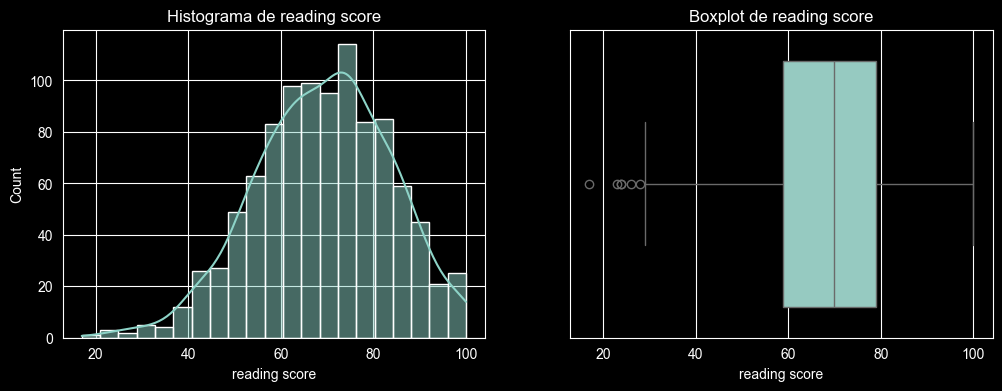

reading score - Skewness: -0.26
reading score - Kurtosis: -0.07
------------------------------


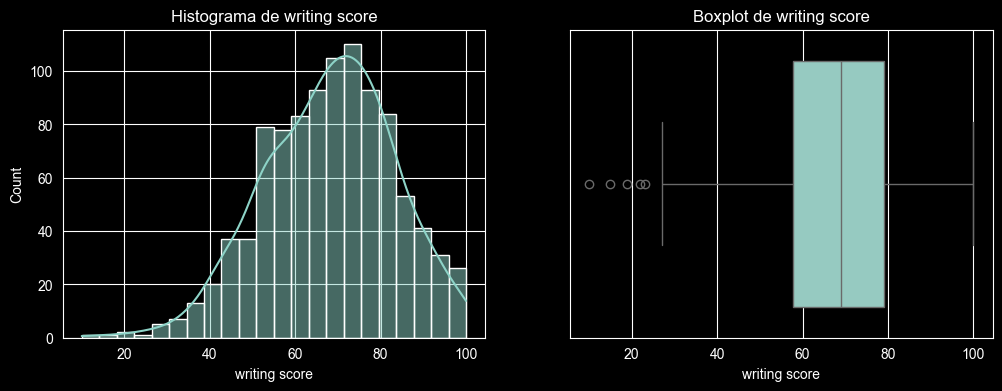

writing score - Skewness: -0.29
writing score - Kurtosis: -0.03
------------------------------


In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histograma
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')
    
    plt.show()
    
    print(f"{col} - Skewness: {df[col].skew():.2f}")
    print(f"{col} - Kurtosis: {df[col].kurt():.2f}")
    print("-" * 30)

## 4. Correlaciones
Visualización de la matriz de correlación mediante un heatmap.

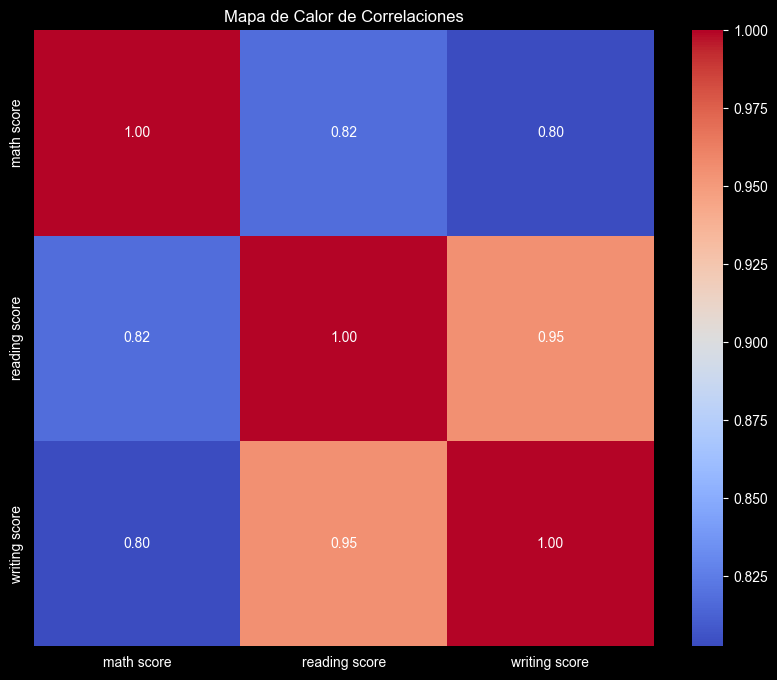

In [4]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Calor de Correlaciones")
plt.show()

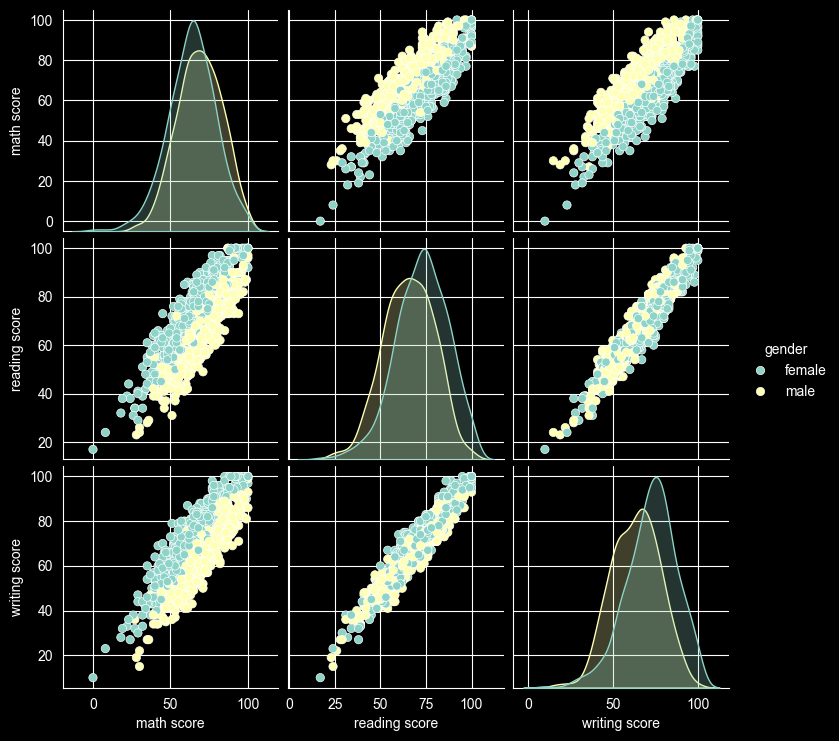

In [13]:
sns.pairplot(df[numeric_cols.union(['gender'])], hue='gender')
plt.show()


## 5. Relaciones Ji-cuadrado (Chi-Square)
Para variables categóricas.

In [14]:
from scipy.stats import chi2_contingency, chi2 as chi2_dist

categorical_cols = df.select_dtypes(include=['object']).columns
results = []
alpha = 0.05

for i in range(len(categorical_cols)):
    for j in range(i + 1, len(categorical_cols)):
        col1 = categorical_cols[i]
        col2 = categorical_cols[j]
        contingency_table = pd.crosstab(df[col1], df[col2])
        chi2_stat, p, dof, expected = chi2_contingency(contingency_table)
        chi2_crit = chi2_dist.ppf(1 - alpha, dof)
        results.append((col1, col2, chi2_stat, chi2_crit, p))

chi_results_df = pd.DataFrame(
    results,
    columns=['Variable 1', 'Variable 2', 'Xi-cuadrado', 'Valor crítico', 'p-value']
)
print("Resultados de Ji-cuadrado (p-value < 0.05 indica relación significativa):")
display(chi_results_df)


Resultados de Ji-cuadrado (p-value < 0.05 indica relación significativa):


,Variable 1,Variable 2,Xi-cuadrado,Valor crítico,p-value
0,gender,race/ethnicity,9.027386,9.487729,0.060419
1,gender,parental level of education,3.384905,11.070498,0.640870
2,gender,lunch,0.371738,3.841459,0.542058
3,gender,test preparation course,0.015529,3.841459,0.900827
4,race/ethnicity,parental level of education,29.458662,31.410433,0.079113
5,race/ethnicity,lunch,3.442350,9.487729,0.486698
6,race/ethnicity,test preparation course,5.487515,9.487729,0.240829
7,parental level of education,lunch,1.111268,11.070498,0.953101
8,parental level of education,test preparation course,9.544071,11.070498,0.089234
9,lunch,test preparation course,0.220954,3.841459,0.638314


## 6. Distancia de Kolmogorov-Smirnov
Comparamos distribuciones de variables respecto a un target (ej: math score median split).

KS Statistic: 0.5958
p-value: 0.0000


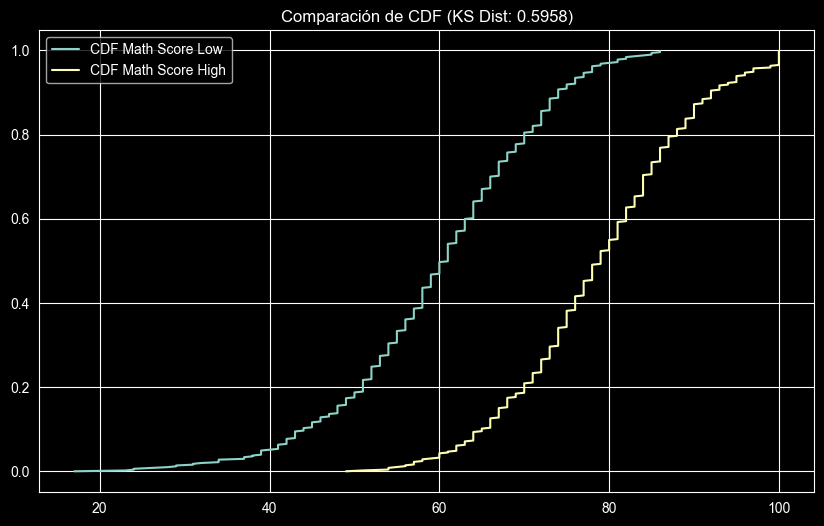

In [10]:
target_col = 'math score'
median_val = df[target_col].median()
group1 = df[df[target_col] <= median_val]['reading score']
group2 = df[df[target_col] > median_val]['reading score']

ks_stat, p_value = stats.ks_2samp(group1, group2)

print(f"KS Statistic: {ks_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Gráfica de CDF
def plot_ks(data1, data2, name1, name2):
    x1 = np.sort(data1)
    y1 = np.arange(len(x1)) / float(len(x1))
    x2 = np.sort(data2)
    y2 = np.arange(len(x2)) / float(len(x2))
    
    plt.figure(figsize=(10, 6))
    plt.plot(x1, y1, label=f'CDF {name1}')
    plt.plot(x2, y2, label=f'CDF {name2}')
    plt.title(f"Comparación de CDF (KS Dist: {ks_stat:.4f})")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_ks(group1, group2, 'Math Score Low', 'Math Score High')

## 7. EDA Automatizado con ydata-profiling

In [11]:
profile = ProfileReport(df, title="Student Exam Performance Dataset")
# En un notebook se puede mostrar directamente:
# profile.to_widgets()
# O guardar a HTML:
profile.to_file("StudentExamPerformance_EDA.html")
print("Reporte generado como 'StudentExamPerformance_EDA.html'")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 356.65it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Reporte generado como 'eda_report.html'
